# 04 — Model Evaluation

**Project:** QLoRA Fine-Tuning for Functional Job Skill Classification

**Model:** Microsoft Phi-3 Mini (`microsoft/Phi-3-mini-4k-instruct`)

**Group 20:** Michael Dong, Haolin Chen

---

This notebook evaluates the fine-tuned Phi-3 Mini model on the held-out test set and provides:

- Baseline vs. fine-tuned comparison (Accuracy, Precision, Recall, F1)
- Per-class classification report
- Confusion matrix for top-N skill categories
- Qualitative prediction examples

Run this notebook after `03_phi3_qlora_training.ipynb` has finished and the LoRA adapters have been saved.

## 1: Install Required Packages

In [58]:
!pip install -q peft accelerate bitsandbytes

## 2: Import Libraries, Set Paths, and Configure Parameters

In [59]:
import bitsandbytes as bnb
import torch

print("bitsandbytes:", bnb.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

bitsandbytes: 0.49.2
CUDA: True
GPU: Tesla T4


In [60]:
import os
import re
import gc
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

from peft import PeftModel


# ==================================================
# Paths
# ==================================================

BASE_MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"


ADAPTER_PATH = (
    "/kaggle/input/datasets/hollychen12345/"
    "phi3-skill-lora-adapter-v2/phi3_skill_lora_adapter_v2"
)

TEST_DATA_PATH = (
    "/kaggle/input/datasets/hollychen12345/"
    "testing-linkedin-post/test.xls"
)


# ==================================================
# Settings
# ==================================================

MAX_INPUT_LEN = 512
MAX_NEW_TOKENS = 6
BATCH_SIZE = 2

EVALUATION_SAMPLE_SIZE = 20
RANDOM_SEED = 42


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Adapter exists:", os.path.exists(ADAPTER_PATH))
print("Test data exists:", os.path.exists(TEST_DATA_PATH))

Device: cuda
GPU: Tesla T4
Adapter exists: True
Test data exists: True


## 3: Verify Adapter Files

In [61]:
print("Adapter files:")

for file_name in os.listdir(ADAPTER_PATH):
    print(file_name)

Adapter files:
adapter_model.safetensors
checkpoint-250
adapter_config.json
README.md
tokenizer.json
tokenizer_config.json
chat_template.jinja
checkpoint-200


## 4: Load the Test Dataset

In [62]:
df_test = pd.read_csv(TEST_DATA_PATH)

print("Original shape:", df_test.shape)

print("\nColumns:")
print(df_test.columns.tolist())

df_test.head(3)

Original shape: (10779, 10)

Columns:
['job_id', 'company_name', 'title', 'description', 'location', 'formatted_work_type', 'formatted_experience_level', 'description_character_count', 'description_word_count', 'skill_name']


,job_id,company_name,title,description,location,formatted_work_type,formatted_experience_level,description_character_count,description_word_count,skill_name
0,3889769292,Beacon Hill Staffing Group,Outpatient Counselor (LCDC),Our team is hiring an outpatient counselors fo...,"Conroe, TX",Full-time,Mid-Senior level,3842,519,Health Care Provider
1,3905348758,Uber,Head of People Operations - US&C,About The Role As the Head of People Operation...,"Seattle, WA",Full-time,Director,3730,547,Human Resources
2,3900976517,Narrative Ads,Content Producer,Who is Narrative?Narrative Ads is a social med...,"Pasadena, CA",Full-time,Not specified,2431,382,"Marketing, Public Relations, Writing/Editing"


## 5: Clean the Test Data

In [63]:
required_columns = [
    "title",
    "description",
    "skill_name"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_test.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# Remove rows without a label
df_test = (
    df_test
    .dropna(subset=["skill_name"])
    .copy()
)


# Clean text columns
df_test["title"] = (
    df_test["title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df_test["description"] = (
    df_test["description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df_test["skill_name"] = (
    df_test["skill_name"]
    .astype(str)
    .str.strip()
)


# Remove rows where both title and description are empty
df_test = df_test[
    (df_test["title"] != "") |
    (df_test["description"] != "")
].copy()


# Build model input
def build_user_prompt(title, description):

    title = str(title).strip()
    description = str(description).strip()

    return (
        "Classify the following job posting into one functional skill category.\n\n"
        f"Job Title:\n{title}\n\n"
        f"Job Description:\n{description}\n\n"
        "Return only the category name."
    )


df_test["instruction"] = df_test.apply(
    lambda row: build_user_prompt(
        row["title"],
        row["description"]
    ),
    axis=1
)


INSTRUCTION_COL = "instruction"
LABEL_COL = "skill_name"


columns_to_keep = [
    column
    for column in [
        "job_id",
        "title",
        "description",
        INSTRUCTION_COL,
        LABEL_COL
    ]
    if column in df_test.columns
]


df_test = (
    df_test[columns_to_keep]
    .drop_duplicates(
        subset=[INSTRUCTION_COL, LABEL_COL]
    )
    .reset_index(drop=True)
)


print("Cleaned test samples:", len(df_test))
print(
    "Unique skill classes:",
    df_test[LABEL_COL].nunique()
)

df_test.head(3)

Cleaned test samples: 10779
Unique skill classes: 655


,job_id,title,description,instruction,skill_name
0,3889769292,Outpatient Counselor (LCDC),Our team is hiring an outpatient counselors fo...,Classify the following job posting into one fu...,Health Care Provider
1,3905348758,Head of People Operations - US&C,About The Role As the Head of People Operation...,Classify the following job posting into one fu...,Human Resources
2,3900976517,Content Producer,Who is Narrative?Narrative Ads is a social med...,Classify the following job posting into one fu...,"Marketing, Public Relations, Writing/Editing"


## 6: Sample 20 Test Examples

In [64]:
if len(df_test) > EVALUATION_SAMPLE_SIZE:

    df_eval = (
        df_test
        .sample(
            n=EVALUATION_SAMPLE_SIZE,
            random_state=RANDOM_SEED
        )
        .reset_index(drop=True)
    )

else:
    df_eval = df_test.copy()


instructions = df_eval[INSTRUCTION_COL].tolist()
ground_truths = df_eval[LABEL_COL].tolist()


print("Evaluation samples:", len(df_eval))

print(
    "Skill classes in evaluation set:",
    df_eval[LABEL_COL].nunique()
)

df_eval[
    ["title", LABEL_COL]
].head()

Evaluation samples: 20
Skill classes in evaluation set: 10


,title,skill_name
0,LICENSED PRACTICAL NURSE (LPN) - YADKIN NURSIN...,Health Care Provider
1,"SPED Teacher - up to $2,204.00/week - Phoenix,AZ","Education, Training"
2,Diet Tech Registered *Food Services Director P...,"Management, Manufacturing"
3,Chief External Officer,"Business Development, Sales"
4,Occupational Therapist,"Administrative, Health Care Provider, Other"


## 7: Configure 4-bit Quantization and Load the Tokenizer

In [65]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)


print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_ID,
    trust_remote_code=False
)


if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


tokenizer.padding_side = "left"

print("Tokenizer loaded.")
print("Pad token:", tokenizer.pad_token)

Loading tokenizer...
Tokenizer loaded.
Pad token: <|endoftext|>


## 8: Define the Prediction Cleaning Function

In [66]:
def clean_prediction(text):
    """
    Clean the generated model output and return one label.
    """

    text = str(text).strip()

    text = re.sub(
        r"^(skill category|skill_name|skill name|answer|response)\s*:\s*",
        "",
        text,
        flags=re.IGNORECASE
    )

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if not lines:
        return "[empty]"

    result = lines[0]

    result = result.strip(
        " \t\n\r\"'`.,;:"
    )

    return result if result else "[empty]"

## 9: Define the Inference Function

In [67]:
def predict_skill(
    model,
    instruction_list,
    batch_size=BATCH_SIZE
):
    predictions = []

    model.eval()

    for start_index in tqdm(
        range(0, len(instruction_list), batch_size),
        desc="Generating predictions"
    ):
        batch_instructions = instruction_list[
            start_index:start_index + batch_size
        ]

        # Convert each instruction into Phi-3 chat format
        batch_prompts = []

        for instruction in batch_instructions:
            messages = [
                {
                    "role": "user",
                    "content": instruction
                }
            ]

            prompt = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            batch_prompts.append(prompt)

        # Tokenize the chat-formatted prompts
        encoded = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_LEN
        )

        encoded = {
            key: value.to(model.device)
            for key, value in encoded.items()
        }

        # Generate predictions
        with torch.inference_mode():
            generated = model.generate(
                **encoded,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                num_beams=1,
                use_cache=True,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id
            )

        # Remove the original prompt tokens
        prompt_length = encoded["input_ids"].shape[1]

        generated_tokens = generated[
            :,
            prompt_length:
        ]

        decoded_outputs = tokenizer.batch_decode(
            generated_tokens,
            skip_special_tokens=True
        )

        # Keep only the first non-empty line
        cleaned_outputs = [
            clean_prediction(output)
            for output in decoded_outputs
        ]

        predictions.extend(cleaned_outputs)

    return predictions

## 10: Load the Baseline Phi-3 Model

In [68]:
!pip install -q -U "bitsandbytes>=0.46.1"

In [69]:
print("Loading baseline Phi-3 model...")

baseline_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16,
    trust_remote_code=False,
    attn_implementation="eager"
)

baseline_model.eval()

print("Baseline model loaded successfully.")

Loading baseline Phi-3 model...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Baseline model loaded successfully.


## 11: Generate Baseline Predictions

In [70]:
print("Running baseline inference...")

baseline_predictions = predict_skill(
    baseline_model,
    instructions,
    batch_size=BATCH_SIZE
)

print("Baseline inference completed.")
print(
    "Number of baseline predictions:",
    len(baseline_predictions)
)


baseline_preview = pd.DataFrame({
    "Ground Truth": ground_truths,
    "Baseline Prediction": baseline_predictions
})

baseline_preview.head(10)

Running baseline inference...


Generating predictions:   0%|          | 0/10 [00:00<?, ?it/s]

Baseline inference completed.
Number of baseline predictions: 20


,Ground Truth,Baseline Prediction
0,Health Care Provider,Geriatric Nursing
1,"Education, Training",for post-secondary education
2,"Management, Manufacturing","responsible, and cooper"
3,"Business Development, Sales",network of supporters and
4,"Administrative, Health Care Provider, Other",in the department.Communic
5,"Business Development, Sales",1(k) planAuto
6,"Finance, Sales",as needed to meet member needs
7,Other,Baseball Coaching
8,"Education, Training",Teaching
9,Health Care Provider,speed internet connection


## 12: Release the Baseline Model

In [71]:
del baseline_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Baseline model removed from GPU memory.")

Baseline model removed from GPU memory.


## 13: Load the Base Model and LoRA Adapter

In [72]:
print("Loading a clean Phi-3 base model...")

finetuned_base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16,
    trust_remote_code=False,
    attn_implementation="eager"
)

print("Base model loaded.")

print("Loading LoRA adapter...")

finetuned_model = PeftModel.from_pretrained(
    finetuned_base_model,
    ADAPTER_PATH
)

finetuned_model.eval()

print("Fine-tuned model loaded successfully.")

Loading a clean Phi-3 base model...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Base model loaded.
Loading LoRA adapter...
Fine-tuned model loaded successfully.


## 14: Generate Fine-tuned Predictions

In [73]:
print("Running fine-tuned inference...")

finetuned_predictions = predict_skill(
    finetuned_model,
    instructions,
    batch_size=BATCH_SIZE
)

print("Fine-tuned inference completed.")

print(
    "Number of fine-tuned predictions:",
    len(finetuned_predictions)
)


finetuned_preview = pd.DataFrame({
    "Ground Truth": ground_truths,
    "Baseline Prediction": baseline_predictions,
    "Fine-tuned Prediction": finetuned_predictions
})

finetuned_preview.head(20)

Running fine-tuned inference...


Generating predictions:   0%|          | 0/10 [00:00<?, ?it/s]

Fine-tuned inference completed.
Number of fine-tuned predictions: 20


,Ground Truth,Baseline Prediction,Fine-tuned Prediction
0,Health Care Provider,Geriatric Nursing,Health Care Provider
1,"Education, Training",for post-secondary education,for life after school Assists
2,"Management, Manufacturing","responsible, and cooper","responsible, and accountable"
3,"Business Development, Sales",network of supporters and,network of supporters and
4,"Administrative, Health Care Provider, Other",in the department.Communic,to the department.Prov
5,"Business Development, Sales",1(k) planAuto,1(k) plan
6,"Finance, Sales",as needed to meet member needs,as needed.Must be
7,Other,Baseball Coaching,Other
8,"Education, Training",Teaching,"Education, Training"
9,Health Care Provider,speed internet connection,speed internet access is required


## 15: Final Verification (Part 1)

In [74]:
print("Ground truths:", len(ground_truths))
print(
    "Baseline predictions:",
    len(baseline_predictions)
)
print(
    "Fine-tuned predictions:",
    len(finetuned_predictions)
)


assert len(ground_truths) == len(baseline_predictions), (
    "Baseline prediction count does not match."
)

assert len(ground_truths) == len(finetuned_predictions), (
    "Fine-tuned prediction count does not match."
)


print("\nAll prediction lengths match.")
print("The first half is complete.")

Ground truths: 20
Baseline predictions: 20
Fine-tuned predictions: 20

All prediction lengths match.
The first half is complete.


## 16：Label Normalization

In [75]:
import re

def normalize_label(text):

    text = str(text).strip().lower()

    text = re.sub(r"\s+", " ", text)

    text = text.replace(".", "")
    text = text.replace(",", ", ")

    return text


ground_truth_norm = [
    normalize_label(x)
    for x in ground_truths
]

baseline_norm = [
    normalize_label(x)
    for x in baseline_predictions
]

finetuned_norm = [
    normalize_label(x)
    for x in finetuned_predictions
]

## 17：Accuracy、Precision、Recall、F1

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

baseline_accuracy = accuracy_score(
    ground_truth_norm,
    baseline_norm
)

finetuned_accuracy = accuracy_score(
    ground_truth_norm,
    finetuned_norm
)

baseline_precision = precision_score(
    ground_truth_norm,
    baseline_norm,
    average="weighted",
    zero_division=0
)

finetuned_precision = precision_score(
    ground_truth_norm,
    finetuned_norm,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    ground_truth_norm,
    baseline_norm,
    average="weighted",
    zero_division=0
)

finetuned_recall = recall_score(
    ground_truth_norm,
    finetuned_norm,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    ground_truth_norm,
    baseline_norm,
    average="weighted",
    zero_division=0
)

finetuned_f1 = f1_score(
    ground_truth_norm,
    finetuned_norm,
    average="weighted",
    zero_division=0
)

metrics_df = pd.DataFrame({
    "Model":[
        "Baseline",
        "Fine-tuned"
    ],
    "Accuracy":[
        baseline_accuracy,
        finetuned_accuracy
    ],
    "Precision":[
        baseline_precision,
        finetuned_precision
    ],
    "Recall":[
        baseline_recall,
        finetuned_recall
    ],
    "F1":[
        baseline_f1,
        finetuned_f1
    ]
})

metrics_df

,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.0,0.00,0.0,0.000000
1,Fine-tuned,0.2,0.65,0.2,0.282381


## 18：Classification Report

In [77]:
from sklearn.metrics import classification_report

print("========== Baseline ==========\n")

print(
    classification_report(
        ground_truth_norm,
        baseline_norm,
        zero_division=0
    )
)

print("\n")

print("========== Fine-tuned ==========\n")

print(
    classification_report(
        ground_truth_norm,
        finetuned_norm,
        zero_division=0
    )
)

========== Baseline ==========

                                                precision    recall  f1-score   support

                          ) and direct deposit       0.00      0.00      0.00       0.0
                                 1(k) planauto       0.00      0.00      0.00       0.0
                                    accounting       0.00      0.00      0.00       0.0
                           accounting/auditing       0.00      0.00      0.00       1.0
accounting/auditing,  administrative,  finance       0.00      0.00      0.00       1.0
 administrative,  health care provider,  other       0.00      0.00      0.00       1.0
                    and trust-building skilled       0.00      0.00      0.00       0.0
                as needed to meet member needs       0.00      0.00      0.00       0.0
                             baseball coaching       0.00      0.00      0.00       0.0
                  business development,  sales       0.00      0.00      0.00       4.0

## 19：Confusion Matrix

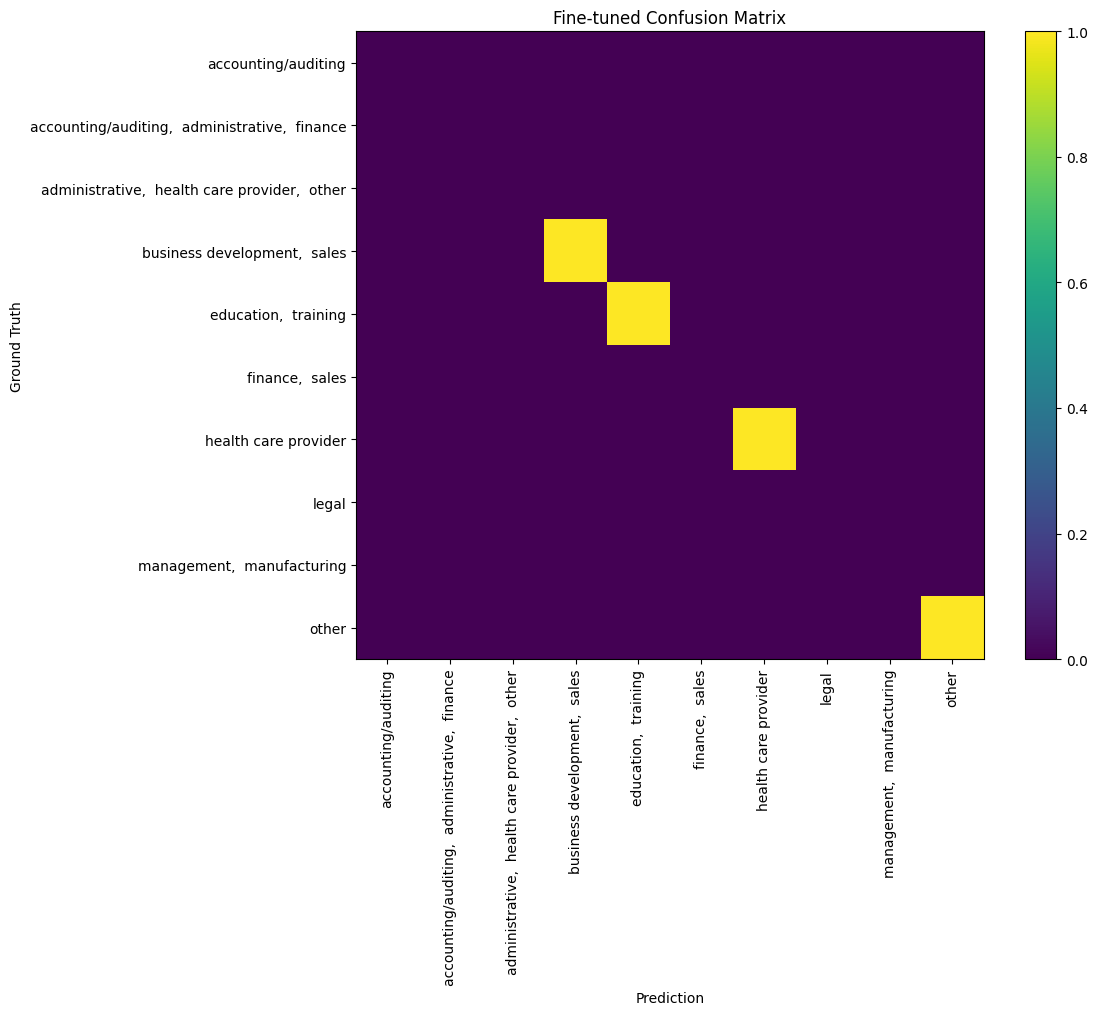

In [78]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import numpy as np

labels = sorted(
    list(
        set(ground_truth_norm)
    )
)

cm = confusion_matrix(
    ground_truth_norm,
    finetuned_norm,
    labels=labels
)

plt.figure(figsize=(12,10))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    np.arange(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    np.arange(len(labels)),
    labels
)

plt.xlabel("Prediction")

plt.ylabel("Ground Truth")

plt.title("Fine-tuned Confusion Matrix")

plt.tight_layout()

plt.show()

## 20: Save results

In [79]:
results_df = df_eval.copy()

results_df["Ground Truth"] = ground_truths

results_df["Baseline Prediction"] = baseline_predictions

results_df["Fine-tuned Prediction"] = finetuned_predictions

results_df["Baseline Correct"] = (
    results_df["Ground Truth"]
    == results_df["Baseline Prediction"]
)

results_df["Fine-tuned Correct"] = (
    results_df["Ground Truth"]
    == results_df["Fine-tuned Prediction"]
)

results_df.to_csv(
    "/kaggle/working/evaluation_results.csv",
    index=False
)

metrics_df.to_csv(
    "/kaggle/working/metrics.csv",
    index=False
)

print("Saved evaluation_results.csv")
print("Saved metrics.csv")

results_df.head(10)

Saved evaluation_results.csv
Saved metrics.csv


,job_id,title,description,instruction,skill_name,Ground Truth,Baseline Prediction,Fine-tuned Prediction,Baseline Correct,Fine-tuned Correct
0,3885103704,LICENSED PRACTICAL NURSE (LPN) - YADKIN NURSIN...,"Liberty Cares With Compassion ****$7,500 Sign ...",Classify the following job posting into one fu...,Health Care Provider,Health Care Provider,Geriatric Nursing,Health Care Provider,False,True
1,3903824846,"SPED Teacher - up to $2,204.00/week - Phoenix,AZ","The Special Education Teacher, under the direc...",Classify the following job posting into one fu...,"Education, Training","Education, Training",for post-secondary education,for life after school Assists,False,False
2,3884831792,Diet Tech Registered *Food Services Director P...,Position Details Employment Status: Full-TimeS...,Classify the following job posting into one fu...,"Management, Manufacturing","Management, Manufacturing","responsible, and cooper","responsible, and accountable",False,False
3,3904366585,Chief External Officer,About The Organization Celebrating 25 years of...,Classify the following job posting into one fu...,"Business Development, Sales","Business Development, Sales",network of supporters and,network of supporters and,False,False
4,3901391152,Occupational Therapist,"$20,000 Sign-On Bonus Available!New Grads Welc...",Classify the following job posting into one fu...,"Administrative, Health Care Provider, Other","Administrative, Health Care Provider, Other",in the department.Communic,to the department.Prov,False,False
5,3888967645,Retail Sales Associate (Part-Time),AutoZone's Part-Time Retail Sales Associates d...,Classify the following job posting into one fu...,"Business Development, Sales","Business Development, Sales",1(k) planAuto,1(k) plan,False,False
6,3904935787,Financial Advisory Services Specialist,If you are motivated and believe in the credit...,Classify the following job posting into one fu...,"Finance, Sales","Finance, Sales",as needed to meet member needs,as needed.Must be,False,False
7,3884431253,SKILL DEVELOPMENT COORDINATOR,ABOUT US:Futures Training Center is the premie...,Classify the following job posting into one fu...,Other,Other,Baseball Coaching,Other,False,True
8,3902729855,4th Grade Teacher – Indian Trail Elementary Sc...,24-25 Teacher Transfer Instructions: Current J...,Classify the following job posting into one fu...,"Education, Training","Education, Training",Teaching,"Education, Training",False,True
9,3884436756,Registered Nurse,Position : Registered NurseLocation : Bronx Ne...,Classify the following job posting into one fu...,Health Care Provider,Health Care Provider,speed internet connection,speed internet access is required,False,False


## 21: Performance Comparison

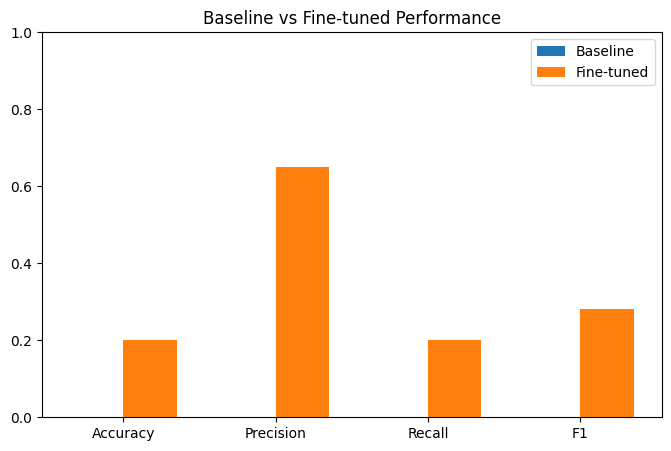

In [80]:
plt.figure(figsize=(8,5))

x = np.arange(4)

width = 0.35

plt.bar(
    x-width/2,
    [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    width,
    label="Baseline"
)

plt.bar(
    x+width/2,
    [
        finetuned_accuracy,
        finetuned_precision,
        finetuned_recall,
        finetuned_f1
    ],
    width,
    label="Fine-tuned"
)

plt.xticks(
    x,
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

plt.ylim(0,1)

plt.legend()

plt.title("Baseline vs Fine-tuned Performance")

plt.show()